# Experiment 02: Model Tuning (XGBoost)

In [2]:
import mlflow

In [13]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Bank_Churn")

<Experiment: artifact_location='/mlflow/artifacts/1', creation_time=1780183529764, experiment_id='1', last_update_time=1780183529764, lifecycle_stage='active', name='Bank_Churn', tags={}, trace_location=None, workspace='default'>

In [4]:
# Импорт библиотек
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib
from datetime import datetime

# Настройки
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Добавляем путь к src
sys.path.append('..')
sys.path.append(os.path.abspath('..'))

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Импортируем наш препроцессор
from src.data.preprocess import DataPreprocessor

print("Библиотеки загружены")
print(f"Версия XGBoost: {xgb.__version__}")

Библиотеки загружены
Версия XGBoost: 3.2.0


In [5]:
# Загрузка конфигурации
config_path = "../configs/config.yaml"
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("Конфигурация загружена из config.yaml")
else:
    config = {
        'random_state': 42,
        'test_size': 0.2
    }
    print("Используется конфигурация по умолчанию")

RANDOM_STATE = config.get('random_state', 42)
TEST_SIZE = config.get('test_size', 0.2)

print(f"Random state: {RANDOM_STATE}")
print(f"Test size: {TEST_SIZE}")

Конфигурация загружена из config.yaml
Random state: 42
Test size: 0.2


In [8]:
# Загрузка и предобработка данных

# Загружаем сырые данные
df_raw = pd.read_csv('../data/raw/Churn_Modelling.csv')
print(f"Загружено {len(df_raw)} записей")
print(f"Исходные колонки: {list(df_raw.columns)}")

# Инициализируем препроцессор
preprocessor = DataPreprocessor()

# Обрабатываем данные (fit_scaler=True для обучения)
X_scaled, y, df_processed = preprocessor.preprocess(df_raw, fit_scaler=True)

# Сохраняем препроцессор для сервиса
os.makedirs('../artifacts', exist_ok=True)
preprocessor.save('../artifacts/preprocessor.pkl')
print("Препроцессор сохранён в artifacts/preprocessor.pkl")

print(f"\nПосле предобработки:")
print(f"  - Признаков: {X_scaled.shape[1]}")
print(f"  - Целевая переменная: {y.name}")
print(f"  - Распределение: {y.value_counts().to_dict()}")

INFO:src.data.preprocess:DataPreprocessor инициализирован
INFO:src.data.preprocess:Создано 21 признаков
INFO:src.data.preprocess:Данные очищены. Форма: (10000, 14)
INFO:src.data.preprocess:Scaler обучен и применён
INFO:src.data.preprocess:Препроцессор сохранён в ../artifacts/preprocessor.pkl


Загружено 10000 записей
Исходные колонки: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Препроцессор сохранён в artifacts/preprocessor.pkl

После предобработки:
  - Признаков: 13
  - Целевая переменная: Exited
  - Распределение: {0: 7963, 1: 2037}


In [9]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nРазделение данных:")
print(f"  - Train: {X_train.shape[0]} записей (отток: {y_train.mean():.2%})")
print(f"  - Test: {X_test.shape[0]} записей (отток: {y_test.mean():.2%})")


Разделение данных:
  - Train: 8000 записей (отток: 20.38%)
  - Test: 2000 записей (отток: 20.35%)


In [10]:
# Сохраняем обработанные данные для отладки (опционально)
df_processed.to_csv('../data/sample/processed_sample.csv', index=False)
print("Обработанные данные сохранены в data/sample/processed_sample.csv")

Обработанные данные сохранены в data/sample/processed_sample.csv


In [11]:
# Baseline Model: Logistic Regression

# Загружаем baseline модель, сохранённую в 01 ноутбуке
baseline_path = '../artifacts/models/logreg_baseline_v1.pkl'

if os.path.exists(baseline_path):
    lr = joblib.load(baseline_path)
    print("Baseline модель загружена из", baseline_path)
else:
    print(f"Ошибка: Файл {baseline_path} не найден!")
    print("Сначала выполните ноутбук 01_eda_and_baseline.ipynb для сохранения модели")
    raise FileNotFoundError(f"Baseline модель не найдена: {baseline_path}")
    
# Предсказания
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

# Метрики
print(f"\nМетрики на тестовой выборке:")
print(f"  - Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  - Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"  - F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"  - ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Baseline модель загружена из ../artifacts/models/logreg_baseline_v1.pkl

Метрики на тестовой выборке:
  - Accuracy:  0.8530
  - Precision: 0.7557
  - Recall:    0.4103
  - F1-Score:  0.5318
  - ROC-AUC:   0.8444


In [15]:
# XGBoost Model (Default)
# Рассчитываем weight для класса меньшинства
total_neg = (y_train == 0).sum()  # 7963
total_pos = (y_train == 1).sum()  # 2037
scale_pos_weight = total_neg / total_pos  # 7963/2037 ≈ 3.91

# Параметры модели
params = {
    'n_estimators': 200,
    'learning_rate': 0.05,
    'max_depth': 3,
    'scale_pos_weight': scale_pos_weight,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE,
    'eval_metric': 'logloss'
}

# Запуск эксперимента в MLflow
with mlflow.start_run(run_name="xgboost_default_v1"):
    # Логирование параметров
    mlflow.log_params(params)
    
    # Обучение модели
    xgb_default = xgb.XGBClassifier(
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        max_depth=params['max_depth'],
        scale_pos_weight=params['scale_pos_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        random_state=params['random_state'],
        eval_metric=params['eval_metric'],
        use_label_encoder=False
    )
    xgb_default.fit(X_train, y_train)
    
    # Предсказания
    y_pred_xgb = xgb_default.predict(X_test)
    y_pred_proba_xgb = xgb_default.predict_proba(X_test)[:, 1]
    
    # Метрики
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred_xgb),
        "precision": precision_score(y_test, y_pred_xgb),
        "recall": recall_score(y_test, y_pred_xgb),
        "f1": f1_score(y_test, y_pred_xgb),
        "roc_auc": roc_auc_score(y_test, y_pred_proba_xgb)
    }
    
    # Логирование метрик
    mlflow.log_metrics(metrics)
    
# Метрики
print(f"\nМетрики на тестовой выборке:")
print(f"  - Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"  - Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"  - F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  - ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

🏃 View run xgboost_default_v1 at: http://127.0.0.1:5000/#/experiments/1/runs/41ee12924b9b4eb3870d21e229e7c227
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

Метрики на тестовой выборке:
  - Accuracy:  0.7930
  - Precision: 0.4942
  - Recall:    0.7322
  - F1-Score:  0.5901
  - ROC-AUC:   0.8577


In [18]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 2, 4, 6]  # Добавить поиск по весам
}
with mlflow.start_run(run_name="xgboost_gridsearch_balanced"):
    
    # Логирование параметров GridSearch
    mlflow.log_param("grid_search_params", str(param_grid))
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("scoring", "roc_auc")
    
    # Создание и обучение GridSearchCV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    grid_search = GridSearchCV(
        xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
        param_grid,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    print("\nЗапуск Grid Search...")
    grid_search.fit(X_train, y_train)
    
    # Логирование лучших параметров
    best_params = grid_search.best_params_
    mlflow.log_params(best_params)
    
    # Логирование метрик
    mlflow.log_metric("best_cv_roc_auc", grid_search.best_score_)
    mlflow.log_metric("best_cv_std", grid_search.cv_results_['std_test_score'][grid_search.best_index_])
    
    # Сохранение всех результатов CV
    cv_results_df = pd.DataFrame(grid_search.cv_results_)
    cv_results_df.to_csv('../artifacts/gridsearch_cv_results.csv', index=False)
    mlflow.log_artifact('../artifacts/gridsearch_cv_results.csv')
    
    # Логирование лучшей модели
    best_xgb = grid_search.best_estimator_
    
    # Предсказания на тестовой выборке
    y_pred_best = best_xgb.predict(X_test)
    y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]
    
    # Метрики на тесте
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
    
    test_metrics = {
        "accuracy": accuracy_score(y_test, y_pred_best),
        "precision": precision_score(y_test, y_pred_best),
        "recall": recall_score(y_test, y_pred_best),
        "f1": f1_score(y_test, y_pred_best),
        "roc_auc": roc_auc_score(y_test, y_pred_proba_best)
    }
    
    mlflow.log_metrics(test_metrics)


Запуск Grid Search...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
🏃 View run xgboost_gridsearch_balanced at: http://127.0.0.1:5000/#/experiments/1/runs/10861fd9856a46baa5788938627f3b50
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [19]:
grid_search.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 200,
 'scale_pos_weight': 1,
 'subsample': 0.8}

In [21]:
feature_names = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                'IsActiveMember', 'Age_Group', 'Tenure_Ratio', 'Balance_Per_Product', 
                'Active_Senior', 'Has_Balance', 'Is_Multi_Product', 'Gender_Male']

In [26]:
# Получаем вероятности предсказаний
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# Поиск оптимального порога
from sklearn.metrics import precision_recall_curve, f1_score

# Получаем precision, recall для разных порогов
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Вычисляем F1-score для каждого порога
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Находим порог с максимальным F1-score
optimal_idx = np.argmax(f1_scores[:-1])  # -1 исключает последний элемент
optimal_threshold = thresholds[optimal_idx]

print(f"Оптимальный порог по F1-score: {optimal_threshold:.4f}")
print(f"F1-score при этом пороге: {f1_scores[optimal_idx]:.4f}")

Оптимальный порог по F1-score: 0.2819
F1-score при этом пороге: 0.6345



Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.76      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



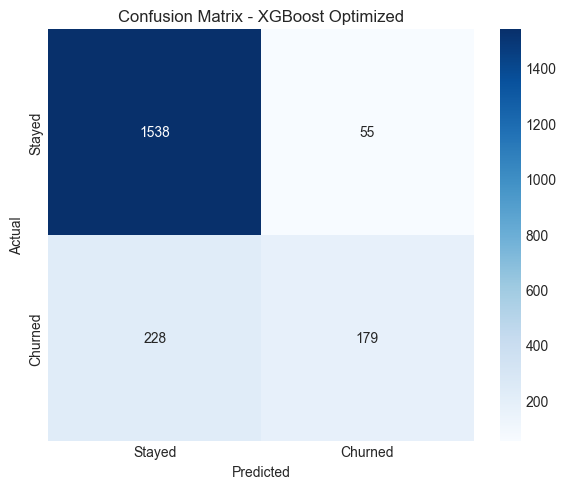


5-Fold Cross-Validation ROC-AUC: 0.8537 (+/- 0.0048)
  - Scores: [0.86046193 0.85264019 0.85274334 0.85669491 0.84608491]


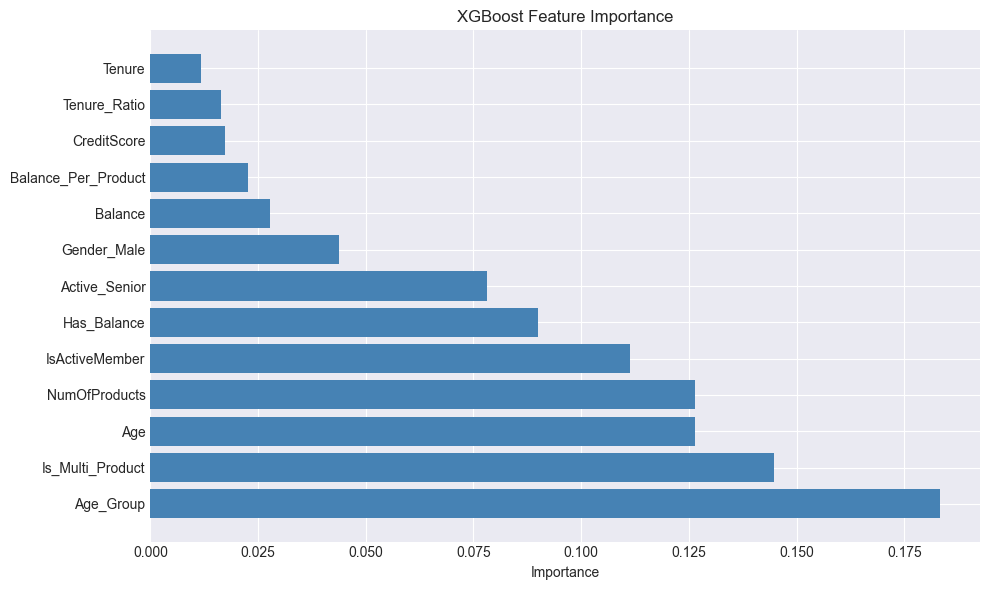


Топ-5 важнейших признаков:
  - Age_Group: 0.1834
  - Is_Multi_Product: 0.1447
  - Age: 0.1265
  - NumOfProducts: 0.1264
  - IsActiveMember: 0.1113


In [22]:
# Детальный анализ лучшей модели (XGBoost Optimized)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix - XGBoost Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../artifacts/xgb_confusion_matrix.png', dpi=150)
plt.show()

# Cross-validation score
cv_scores = cross_val_score(best_xgb, X_scaled, y, cv=5, scoring='roc_auc')
print(f"\n5-Fold Cross-Validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  - Scores: {cv_scores}")

# Feature Importance (XGBoost)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('../artifacts/xgb_feature_importance.png', dpi=150)
plt.show()

print("\nТоп-5 важнейших признаков:")
for i, row in importance_df.head(5).iterrows():
    print(f"  - {row['Feature']}: {row['Importance']:.4f}")

In [25]:
# Сохранение финальной модели

# Сохраняем лучшую модель
joblib.dump(best_xgb, '../artifacts/models/xgb_final_v1.pkl')
print("Модель сохранена в artifacts/models/xgb_final_v1.pkl")

# Сохраняем метаданные эксперимента
experiment_metadata = {
    'experiment_date': datetime.now().isoformat(),
    'model_type': 'XGBoost',
    'best_params': grid_search.best_params_,
    'test_roc_auc': float(roc_auc_score(y_test, y_pred_proba_best)),
    'test_f1': float(f1_score(y_test, y_pred_best)),
    'cv_mean': float(cv_scores.mean()),
    'cv_std': float(cv_scores.std()),
    'features': feature_names,
    'feature_importance': importance_df.to_dict('records')
}

with open('../artifacts/experiment_metadata.yaml', 'w') as f:
    yaml.dump(experiment_metadata, f, default_flow_style=False)
print("Метаданные эксперимента сохранены в artifacts/experiment_metadata.yaml")

Модель сохранена в artifacts/models/xgb_final_v1.pkl
Метаданные эксперимента сохранены в artifacts/experiment_metadata.yaml


**Результаты эксперимента:**


1. **XGBoost (Optimized)**
   - ROC-AUC: 0.8537

2. **Ключевые признаки оттока:**
   - Age_Group: 0.1834
   - Is_Multi_Product: 0.1447
   - Age: 0.1265
   - NumOfProducts: 0.1264
   - IsActiveMember: 0.1113